In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case)

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/11100
11100


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [7]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [8]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [9]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [10]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [11]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [12]:
# get initial parameters and target states

i_stepsize = 5
i_range = range(0, len(exc),i_stepsize)
i_range_0 = range(0, len(exc),i_stepsize)
i_range_1 = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.750000000000000

In [13]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  5 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  0 , total integrated cost =  5097.289828199723
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9111.456490210901
Gradient descend method:  None
RUN  0 , total integrated cost =  9111.456490210901
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  15 0.4500000000000001 0.4500000000000002

RUN  0 , total integrated cost =  38727.35641379273
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  135 0.5250000000000001 0.8750000000000006
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636143093983
Gradient descend method:  None
RUN  0 , total integrated cost =  23532.636143093983
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10019.968518582271
Gradient descend method:  None
RUN  0 , total integrated cost =  10019.968518582271
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  145 0.5750000000000002 0.9000000000000006
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33290.05146687772
Gradient descend method:  None
RUN  0 , total integrated cost =  33290.05

In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    
    if not type(bestControl_init[i]) == type(None):
        continue
        
    control0 = aln.getZeroControl()

    ##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.750000000000000

--------- 0


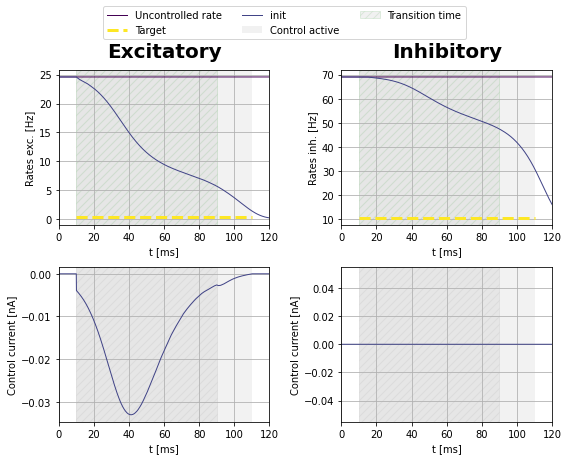

In [15]:

#plot initial guesses
for i in i_range[:1]:
    print("---------", i)
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [16]:
found_solution = []
no_solution = []
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break


    for i in i_range:
        print("------- ", i, exc[i], inh[i])        

        if np.abs(np.mean(bestState_init[i][0,0,-300:]) - target[i][0,0,-1]) < 0.1 * np.abs(
            np.mean(bestState_init[i][0,0,-100:]) - bestState_init[i][0,0,0]) and np.abs(
            np.mean(bestState_init[i][0,1,-100:]) - target[i][0,1,-1]) < 0.5 * np.abs(
            np.mean(bestState_init[i][0,1,-100:]) - bestState_init[i][0,1,0]) and np.amin(
            bestState_init[i][0,0,:]) > target[i][0,0,-1] - 5. and np.amin(
            bestState_init[i][0,1,:]) > target[i][0,1,-1] - 5.:
            # and np.amin(bestState_init[i][0,0,:]) > bestState_init[i][0,0,0] - 1.
            #and np.amin(bestState_init[i][0,1,:]) > bestState_init[i][0,1,0] - 1.:
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue
            
        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_, already_tried[i])

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
        
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)

------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  5 0.4000000000000001 0.40000000000000013
found solution for  5
-------  10 0.4250000000000001 0.42500000000000016
found solution for  10
-------  15 0.4500000000000001 0.4500000000000002
[0, 5, 10] []
closest index  10 []
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12785.254906430642
Gradient descend method:  None
RUN  1 , total integrated cost =  230.32869726697265
RUN  2 , total integrated cost =  165.24279224682547
RUN  3 , total integrated cost =  115.90060836120497
RUN  4 , total integrated cost =  94.99293003330983
RUN  5 , total integrated cost =  80.2508971060806
RUN  6 , total integrated cost =  70.53756377096565
RUN  7 , total integrated c

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  105 , total integrated cost =  30.237661666090197
Improved over  105  iterations in  39.928459299728274  seconds by  99.76349582478107  percent.
Problem in initial value trasfer:  Vmean_exc -66.43335969402452 -66.44921053417941
weight =  4305.251769830297
set cost params:  1.0 4305.251769830297 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12549.555264421859
Gradient descend method:  None
RUN  1 , total integrated cost =  10835.271418631026
RUN  2 , total integrated cost =  10830.115340406797
RUN  3 , total integrated cost =  10827.68380487533
RUN  4 , total integrated cost =  10827.275160626563
RUN  5 , total integrated cost =  10798.717255611591
RUN  6 , total integrated cost =  10790.168839237027
RUN  7 , total integrated cost =  10790.139554105539
RUN  8 , total integrated cost =  10790.138348893019
RUN  9 , total integrated cost =  10790.138190351392
RUN  10 , total integrated cost =  10790.13816764719
RUN  11 , t

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  10790.138154217302
RUN  16 , total integrated cost =  10790.138154217302
Control only changes marginally.
RUN  16 , total integrated cost =  10790.138154217302
Improved over  16  iterations in  1.2592147160321474  seconds by  14.019756661756176  percent.
Problem in initial value trasfer:  Vmean_exc -57.70496650104964 -57.702842498030776
-------  20 0.4500000000000001 0.4750000000000002
[0, 5, 10] []
closest index  10 []
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12490.188393155184
Gradient descend method:  None
RUN  1 , total integrated cost =  217.3229282205212
RUN  2 , total integrated cost =  160.00212664921256
RUN  3 , total integrated cost =  113.39458797477288
RUN  4 , total integrated cost =  93.24889937390466
RUN  5 , total integrated cost =  78.03544644639398
RUN  6 , total integrated cost =  67.56283190119365
RUN  7 , total integrated cost =  59.782969080323866

...

RUN  7 , total integrated cost =  14604.345395616445
RUN  8 , total integrated cost =  14604.345395616445
Control only changes marginally.
RUN  8 , total integrated cost =  14604.345395616445
Improved over  8  iterations in  0.7449845504015684  seconds by  35.313691826192226  percent.
Problem in initial value trasfer:  Vmean_exc -56.67067313805046 -56.6727317458398
-------  100 0.4500000000000001 0.7750000000000005
-------  105 0.5750000000000002 0.7750000000000005
[0, 5, 10, 25, 30, 55, 70, 85, 100, 115, 125, 140, 20, 50, 110] [85, 100, 125, 115, 70, 140, 55, 30, 25, 10, 5, 0, 20, 50]
closest index  110 [85, 100, 125, 115, 70, 140, 55, 30, 25, 10, 5, 0, 20, 50]
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  32269.62630325514
Gradient descend method:  None
RUN  1 , total integrated cost =  803.8826469486248
RUN  2 , total integrated cost =  546.9565070363452
RUN  3 , total integrated cost =  360.413225499655


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  75 , total integrated cost =  156.58283001279028
Improved over  75  iterations in  4.275876907631755  seconds by  99.51476714188972  percent.
Problem in initial value trasfer:  Vmean_exc -61.866817307358005 -61.875416657946474
weight =  2164.4167873068786
set cost params:  1.0 2164.4167873068786 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  31605.051357496162
Gradient descend method:  None
RUN  1 , total integrated cost =  31139.538470803815
RUN  2 , total integrated cost =  20980.003489424467
RUN  3 , total integrated cost =  20628.297799073174
RUN  4 , total integrated cost =  20553.907790220757
RUN  5 , total integrated cost =  20553.90779022075


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  20553.90779022075
Control only changes marginally.
RUN  6 , total integrated cost =  20553.90779022075
Improved over  6  iterations in  0.7010253444314003  seconds by  34.96638382982496  percent.
Problem in initial value trasfer:  Vmean_exc -56.68993099053495 -56.69221175725112
-------  110 0.5000000000000002 0.8000000000000005
-------  115 0.4250000000000001 0.8250000000000005
-------  120 0.5500000000000003 0.8250000000000005
closest index  -1 [100, 125, 85, 115, 140, 70, 55, 30, 25, 10, 5, 0, 20, 50, 110]
set cost params:  1.0 10.0 0.0
all options tried already
-------  125 0.47500000000000014 0.8500000000000005
-------  130 0.6000000000000003 0.8500000000000005
closest index  -1 [125, 140, 100, 85, 115, 70, 55, 30, 25, 10, 5, 0, 20, 50, 110]
set cost params:  1.0 10.0 0.0
all options tried already
-------  135 0.5250000000000001 0.8750000000000006
closest index  -1 [125, 140, 115, 100, 85, 70, 55, 30, 25, 10, 5, 0, 20, 50, 110]
set cost params:  1.

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print("------------------------------------------------")
    print('-------------------------', counter)
    
    if counter > 20:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_init[i] == [True, True]:
            continue
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
                       
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
    counter += 1

------------------------------------------------
------------------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  15200.710232808415
set cost params:  1.0 15200.710232808415 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5875.040864335242
Gradient descend method:  None
RUN  1 , total integrated cost =  5874.374953114122
RUN  2 , total integrated cost =  5874.374953114106
RUN  3 , total integrated cost =  5874.374953114103


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  5874.374953114103
Control only changes marginally.
RUN  4 , total integrated cost =  5874.374953114103
Improved over  4  iterations in  0.6694408599287271  seconds by  0.011334580244053427  percent.
Problem in initial value trasfer:  Vmean_exc -59.67105051584243 -59.69422944385117
no convergence
-------  5 0.4000000000000001 0.40000000000000013
weight =  26187.130458348674
set cost params:  1.0 26187.130458348674 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5074.961766653717
Gradient descend method:  None
RUN  1 , total integrated cost =  4993.257205194387
RUN  2 , total integrated cost =  4356.451633514245
RUN  3 , total integrated cost =  4355.375108386065
RUN  4 , total integrated cost =  4355.351478924108
RUN  5 , total integrated cost =  4355.3504482480685
RUN  6 , total integrated cost =  4355.350391491518
RUN  7 , total integrated cost =  4355.3503885980845
RUN  8 , total integrated cost =  4355.350388462179
RUN  9

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  4355.350388453145
Control only changes marginally.
RUN  13 , total integrated cost =  4355.350388453145
Improved over  13  iterations in  1.0837609767913818  seconds by  14.17964137048196  percent.
Problem in initial value trasfer:  Vmean_exc -56.63155477276472 -56.63142972999077
no convergence
-------  10 0.4250000000000001 0.42500000000000016
weight =  8215.97444342665
set cost params:  1.0 8215.97444342665 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9099.208934832799
Gradient descend method:  None
RUN  1 , total integrated cost =  8700.156716740214
RUN  2 , total integrated cost =  6899.165607925421
RUN  3 , total integrated cost =  6861.902792432809
RUN  4 , total integrated cost =  6854.999131422069
RUN  5 , total integrated cost =  6851.196519642274
RUN  6 , total integrated cost =  6851.19651964227
RUN  7 , total integrated cost =  6851.196519642269
RUN  8 , total integrated cost =  6851.196519642269
Control only

...

RUN  4 , total integrated cost =  37148.895436787134
RUN  5 , total integrated cost =  37148.895436787134
Control only changes marginally.
RUN  5 , total integrated cost =  37148.895436787134
Improved over  5  iterations in  0.6149948071688414  seconds by  0.008004578176155519  percent.
Problem in initial value trasfer:  Vmean_exc -56.701678276279665 -56.70153984940874
no convergence
-------  135 0.5250000000000001 0.8750000000000006
weight =  32438.81639103503
set cost params:  1.0 32438.81639103503 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22581.89603754777
Gradient descend method:  None
RUN  1 , total integrated cost =  22580.314971689895
RUN  2 , total integrated cost =  22580.31283469782


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  22580.312834697816
RUN  4 , total integrated cost =  22580.312834697812
RUN  5 , total integrated cost =  22580.312834697812
Control only changes marginally.
RUN  5 , total integrated cost =  22580.312834697812
Improved over  5  iterations in  0.3946023564785719  seconds by  0.007010938529361965  percent.
Problem in initial value trasfer:  Vmean_exc -56.6991036395253 -56.69922383242558
no convergence
-------  140 0.4500000000000001 0.9000000000000006
-------  145 0.5750000000000002 0.9000000000000006
weight =  27665.5794246
set cost params:  1.0 27665.5794246 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  31936.178884828772
Gradient descend method:  None
RUN  1 , total integrated cost =  31933.66325970179
RUN  2 , total integrated cost =  31933.660404694965


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  31933.66040469496
RUN  4 , total integrated cost =  31933.66040469496
Control only changes marginally.
RUN  4 , total integrated cost =  31933.66040469496
Improved over  4  iterations in  0.353128032758832  seconds by  0.007885978290929074  percent.
Problem in initial value trasfer:  Vmean_exc -56.704033341266694 -56.70400955008573
no convergence
------------------------------------------------
------------------------- 21


In [18]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [19]:
factor_iteration = 20
conv_0 = [[False]*2] * len(exc)
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 20:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  15547.856081971799
set cost params:  1.0 15547.856081971799 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.026875333881
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5902.026875333881
Control only changes marginally.
RUN  1 , total integrated cost =  5902.026875333881
Improved over  1  iterations in  0.5625490434467793  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -59.658027160927944 -59.68115694865456
converged for  0
-------  5 0.4000000000000001 0.40000000000000013
weight =  314663.7374643988
set cost params:  1.0 314663.7374643988 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5034.419598127178
Gradient descend method:  None
RUN  1 , total integrated cost =  5034.409496298145
RUN  2 , total integrated cost =  5034.40949629814
RUN  3 , total integrated cost =  5034.409496298136


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  5034.409496298136
Control only changes marginally.
RUN  4 , total integrated cost =  5034.409496298136
Improved over  4  iterations in  1.0819651614874601  seconds by  0.0002006552859796784  percent.
Problem in initial value trasfer:  Vmean_exc -56.624551483476324 -56.62455077625507
no convergence
-------  10 0.4250000000000001 0.42500000000000016
weight =  176076.89784462468
set cost params:  1.0 176076.89784462468 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8994.25332250869
Gradient descend method:  None
RUN  1 , total integrated cost =  8994.233105418003
RUN  2 , total integrated cost =  8994.23310135467
RUN  3 , total integrated cost =  8994.233101348324
RUN  4 , total integrated cost =  8994.233101348322
RUN  5 , total integrated cost =  8994.233101348316
RUN  6 , total integrated cost =  8994.233101348314


...

RUN  4 , total integrated cost =  38323.86473996629
Control only changes marginally.
RUN  4 , total integrated cost =  38323.86473996629
Improved over  4  iterations in  1.5493682529777288  seconds by  0.00011657054156444246  percent.
Problem in initial value trasfer:  Vmean_exc -56.700589718517946 -56.70054661615105
no convergence
-------  135 0.5250000000000001 0.8750000000000006
weight =  128551.31867207025
set cost params:  1.0 128551.31867207025 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23288.330327159925
Gradient descend method:  None
RUN  1 , total integrated cost =  23288.30323914037
RUN  2 , total integrated cost =  23288.303239140332


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  23288.303239140332
Control only changes marginally.
RUN  3 , total integrated cost =  23288.303239140332
Improved over  3  iterations in  1.083808185532689  seconds by  0.00011631585094562524  percent.
Problem in initial value trasfer:  Vmean_exc -56.70030989580454 -56.7003360685741
no convergence
-------  140 0.4500000000000001 0.9000000000000006
-------  145 0.5750000000000002 0.9000000000000006
weight =  110288.61957127968
set cost params:  1.0 110288.61957127968 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  32943.58849311611
Gradient descend method:  None
RUN  1 , total integrated cost =  32943.55174936331
RUN  2 , total integrated cost =  32943.551749363294
RUN  3 , total integrated cost =  32943.55174936329


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  32943.55174936329
Control only changes marginally.
RUN  4 , total integrated cost =  32943.55174936329
Improved over  4  iterations in  1.5649232044816017  seconds by  0.00011153536850372348  percent.
Problem in initial value trasfer:  Vmean_exc -56.70369591180468 -56.703681786334954
no convergence
--------------- 21


In [20]:
"""
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
"""

'\nfor i in i_range_0:\n    \n    aln.params.mue_ext_mean = exc[i] * 5.\n    aln.params.mui_ext_mean = inh[i] * 5.\n\n    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],\n        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,\n        dur_pre, dur_post, initVars[i], target[i], \'\', filename_ = \'\', transition_time_ = trans_time,\n        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)\n'

In [21]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [22]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.5378505110060594
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.5378505110060594
Control only changes marginally.
RUN  1 , total integrated cost =  0.5378505110060594
Improved over  1  iterations in  0.15618161112070084  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -62.903134096071284 -62.902107612239625
converged for  0
-------  5 0.4000000000000001 0.40000000000000013
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.2326597769386678
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.2326597769386678
Control only changes marginally.
RUN  1 , total integrated cost =  0.2326597769386678
Improved over  1  iterations in  0.199823634698987  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -67.92975124368594 -67.9326110977071
converged for  5
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.2358520633185215
Gradient descend method:  None


...

RUN  1 , total integrated cost =  9.289318907808353
Control only changes marginally.
RUN  1 , total integrated cost =  9.289318907808353
Improved over  1  iterations in  0.2886781841516495  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -67.80376066002407 -67.83107436959659
converged for  135
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.3620041721256726
Gradient descend method:  None
RUN  1 , total integrated cost =  1.3620041721256726
Control only changes marginally.
RUN  1 , total integrated cost =  1.3620041721256726
Improved over  

ERROR:root:Problem in initial value trasfer


1  iterations in  0.18994299322366714  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.72819295046733 -73.76336696876663


ERROR:root:Problem in initial value trasfer


converged for  140
-------  145 0.5750000000000002 0.9000000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16.366086186317357
Gradient descend method:  None
RUN  1 , total integrated cost =  16.366086186317357
Control only changes marginally.
RUN  1 , total integrated cost =  16.366086186317357
Improved over  1  iterations in  0.1728144772350788  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -64.85538101940003 -64.87134694776677
converged for  145
--------------- 2
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
full convergence
